# Olist Dataset Initial Exploration

This notebook contains the first exploratory pass over selected Olist source tables and mapping files.  
The goal here is not to build transformations yet, but to understand the structure of the raw data, spot obvious data quality issues, and note assumptions that will matter in Bronze/Silver/Gold layers later.


# What this notebook covers

- quick inventory of CSV files from `source` and `mappings`
- structural inspection with Polars
- first observations on selected business entities
- identification of issues worth handling during transformation

In [39]:
import polars as pl
import matplotlib.pyplot as plt

from pathlib import Path

In [40]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATASETS_DIR = PROJECT_ROOT / "datasets"
SOURCE_DIR = DATASETS_DIR / "source"
MAPPINGS_DIR = DATASETS_DIR / "mappings"

# Dataset inventory

Before diving into individual tables, it is useful to review the available files and compare:
- total row count
- number of unique rows
- number of columns

This gives a quick sanity check of dataset size and helps detect possible duplicate-heavy files early.

In [41]:
# Rows/cols for each file (source + mappings)
records = []
for path in [*SOURCE_DIR.glob("*.csv"), *MAPPINGS_DIR.glob("*.csv")]:
    filename = path.name
    n_cols = len(pl.read_csv(path, n_rows=0).columns)
    n_rows = pl.scan_csv(path).select(pl.len().alias("n")).collect().item()
    n_unique_rows = pl.scan_csv(path).unique().select(pl.len().alias("n")).collect().item()
    records.append({"file": filename, "rows": int(n_rows), "unique_rows": int(n_unique_rows), "cols": int(n_cols)})



pl.DataFrame(records).sort("rows", descending=True)


file,rows,unique_rows,cols
str,i64,i64,i64
"""olist_geolocation_dataset.csv""",1000163,738332,5
"""olist_order_items_dataset.csv""",112650,112650,7
"""olist_order_payments_dataset.c…",103886,103886,5
"""olist_order_reviews_dataset_tr…",100000,100000,7
"""olist_customers_dataset.csv""",99441,99441,5
"""olist_orders_dataset.csv""",99441,99441,8
"""olist_order_reviews_dataset.cs…",99224,99224,7
"""olist_products_dataset.csv""",32951,32951,9
"""olist_sellers_dataset.csv""",3095,3095,4


# Geolocation

This table is useful for understanding how zip-code–level geographic information is represented in the raw data.  
At this stage, the objective is to inspect schema and descriptive statistics rather than resolve geographic inconsistencies.

In [42]:
geolocation_df = pl.read_csv(SOURCE_DIR / "olist_geolocation_dataset.csv")

geolocation_df.describe()

statistic,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
str,f64,f64,f64,str,str
"""count""",1.000163e6,1.000163e6,1.000163e6,"""1000163""","""1000163"""
"""null_count""",0.0,0.0,0.0,"""0""","""0"""
"""mean""",36574.166466,-21.176153,-46.390541,null,null
"""std""",30549.33571,5.715866,4.269748,null,null
"""min""",1001.0,-36.605374,-101.466766,"""* cidade""","""AC"""
"""25%""",11075.0,-23.603545,-48.573137,null,null
"""50%""",26530.0,-22.919377,-46.637879,null,null
"""75%""",63504.0,-19.979614,-43.767703,null,null
"""max""",99990.0,45.065933,121.105394,"""óleo""","""TO"""


At least one city value starts with an asterisk (for example, `* cidade`), which suggests a data quality issue in the raw dataset. This case should be handled during the cleaning stage.

# Order items

`order_items` is one of the core fact-like datasets because it describes the content of each order at line level.  
A quick look at this table helps us understand item granularity, pricing fields, freight fields, and whether there are columns that may require derived metrics later.

In [43]:
order_items_df = pl.read_csv(SOURCE_DIR / "olist_order_items_dataset.csv")

order_items_df.describe()

statistic,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
str,str,f64,str,str,str,f64,f64
"""count""","""112650""",112650.0,"""112650""","""112650""","""112650""",112650.0,112650.0
"""null_count""","""0""",0.0,"""0""","""0""","""0""",0.0,0.0
"""mean""",null,1.197834,null,null,null,120.653739,19.99032
"""std""",null,0.705124,null,null,null,183.633928,15.806405
"""min""","""00010242fe8c5a6d1ba2dd792cb162…",1.0,"""00066f42aeeb9f3007548bb9d3f33c…","""0015a82c2db000af6aaaf3ae2ecb05…","""2016-09-19 00:15:34""",0.85,0.0
"""25%""",null,1.0,null,null,null,39.9,13.08
"""50%""",null,1.0,null,null,null,74.99,16.26
"""75%""",null,1.0,null,null,null,134.9,21.15
"""max""","""fffe41c64501cc87c801fd61db3f62…",21.0,"""fffe9eeff12fcbd74a2f2b007dde0c…","""ffff564a4f9085cd26170f47323937…","""2020-04-09 22:35:08""",6735.0,409.68


# Order payments

This table is important because payment behavior is often more complex than it first appears:
- one order may have one or multiple payment records
- payment type distribution may matter for BI
- installment-related fields can affect downstream reporting logic

The following checks help verify row-level structure and basic cardinality.

In [45]:
order_payments_df = pl.read_csv(SOURCE_DIR / "olist_order_payments_dataset.csv")

order_payments_df.describe()

statistic,order_id,payment_sequential,payment_type,payment_installments,payment_value
str,str,f64,str,f64,f64
"""count""","""103886""",103886.0,"""103886""",103886.0,103886.0
"""null_count""","""0""",0.0,"""0""",0.0,0.0
"""mean""",null,1.092679,null,2.853349,154.10038
"""std""",null,0.706584,null,2.687051,217.494064
"""min""","""00010242fe8c5a6d1ba2dd792cb162…",1.0,"""boleto""",0.0,0.0
"""25%""",null,1.0,null,1.0,56.79
"""50%""",null,1.0,null,1.0,100.0
"""75%""",null,1.0,null,4.0,171.84
"""max""","""fffe41c64501cc87c801fd61db3f62…",29.0,"""voucher""",24.0,13664.08


In [46]:
order_payments_df["order_id"].unique().count()

99440

Some orders are associated with multiple payment records, which means that `order_id` is not unique in this table. This suggests that the dataset stores payments at the payment-event level rather than at the order level. The exact business reasons behind multiple rows per order should be examined further.

In [48]:
order_payments_df["payment_type"].unique()

payment_type
str
"""boleto"""
"""credit_card"""
"""debit_card"""
"""voucher"""
"""not_defined"""


The payment table contains several payment types, including `boleto`, `credit_card`, `debit_card`, `voucher`, and `not_defined`. Some of these categories may require additional business interpretation during transformation and reporting design.

# Order reviews

Reviews are especially interesting because they combine business information with messy text data.  
In raw form, this kind of table often contains nulls, inconsistent text, encoding quirks, and weakly standardized timestamps.

In [49]:
order_reviews_df = pl.read_csv(SOURCE_DIR / "olist_order_reviews_dataset.csv")

order_reviews_df.describe()

statistic,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
str,str,str,f64,str,str,str,str
"""count""","""99224""","""99224""",99224.0,"""11568""","""40977""","""99224""","""99224"""
"""null_count""","""0""","""0""",0.0,"""87656""","""58247""","""0""","""0"""
"""mean""",null,null,4.086421,null,null,null,null
"""std""",null,null,1.347579,null,null,null,null
"""min""","""0001239bc1de2e33cb583967c2ca4c…","""00010242fe8c5a6d1ba2dd792cb162…",1.0,""" """,""" ""","""2016-10-02 00:00:00""","""2016-10-07 18:32:28"""
"""25%""",null,null,4.0,null,null,null,null
"""50%""",null,null,5.0,null,null,null,null
"""75%""",null,null,5.0,null,null,null,null
"""max""","""fffefe7a48d22f7b32046421062219…","""fffe41c64501cc87c801fd61db3f62…",5.0,"""🔟 ""","""😡😡😡😡😡👎👎👎👎👎 Empresa sem compro…","""2018-08-31 00:00:00""","""2018-10-29 12:27:35"""


### Translated reviews mapping

Here the notebook inspects the translated review dataset from the `mappings` directory.  
This is useful because translation artifacts can introduce their own quality issues and may not align perfectly with the original review table.


In [51]:
order_reviews_translated_df = pl.read_csv(MAPPINGS_DIR / "olist_order_reviews_dataset_translated.csv")

order_reviews_translated_df.describe()

statistic,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
str,str,str,f64,str,str,str,str
"""count""","""100000""","""100000""",100000.0,"""11711""","""41725""","""100000""","""100000"""
"""null_count""","""0""","""0""",0.0,"""88289""","""58275""","""0""","""0"""
"""mean""",null,null,4.07089,null,null,null,null
"""std""",null,null,1.359663,null,null,null,null
"""min""","""0001239bc1de2e33cb583967c2ca4c…","""00010242fe8c5a6d1ba2dd792cb162…",1.0,"""!!!!!!!""","""!!!!!!""","""2016-10-02""","""2016-10-07 18:32:28"""
"""25%""",null,null,4.0,null,null,null,null
"""50%""",null,null,5.0,null,null,null,null
"""75%""",null,null,5.0,null,null,null,null
"""max""","""fffefe7a48d22f7b32046421062219…","""fffe41c64501cc87c801fd61db3f62…",5.0,"""🔟""","""😡😡😡😡😡👎👎👎👎👎 Company without com…","""2018-08-31""","""2018-10-29 12:27:35"""


The translated review dataset contains more rows than the original review table, which suggests that the two sources may not align perfectly and should be validated during the transformation stage. Some review texts also contain emoji and other non-standard characters, which may require normalization depending on how the text is used later. Some translated titles contain values such as `!!!!!!`, which may represent noisy or weakly informative text rather than meaningful review content. Also, `review_creation_date` appears to be stored as a date rather than a full datetime value. This difference should be taken into account during transformation and schema alignment.

# Customers

The customer table is central for user-level analytics, customer segmentation, retention analysis, and potential ML use cases. At this stage, the focus is on structure and general completeness patterns.

In [53]:
customers_df = pl.read_csv(SOURCE_DIR / "olist_customers_dataset.csv")

customers_df.describe()

statistic,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
str,str,str,f64,str,str
"""count""","""99441""","""99441""",99441.0,"""99441""","""99441"""
"""null_count""","""0""","""0""",0.0,"""0""","""0"""
"""mean""",null,null,35137.474583,null,null
"""std""",null,null,29797.938996,null,null
"""min""","""00012a2ce6f8dcda20d059ce984917…","""0000366f3b9a7992bf8c76cfdf3221…",1003.0,"""abadia dos dourados""","""AC"""
"""25%""",null,null,11347.0,null,null
"""50%""",null,null,24416.0,null,null
"""75%""",null,null,58900.0,null,null
"""max""","""ffffe8b65bbe3087b653a978c870db…","""ffffd2657e2aad2907e67c3e9daecb…",99990.0,"""zortea""","""TO"""


# Orders

`orders` is one of the main backbone tables of the dataset.  
It links customer activity, order lifecycle timestamps, and fulfillment status, so understanding this table is critical before designing the analytical model.

In [55]:
orders_df = pl.read_csv(SOURCE_DIR / "olist_orders_dataset.csv")

orders_df.describe()

statistic,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
str,str,str,str,str,str,str,str,str
"""count""","""99441""","""99441""","""99441""","""99441""","""99281""","""97658""","""96476""","""99441"""
"""null_count""","""0""","""0""","""0""","""0""","""160""","""1783""","""2965""","""0"""
"""mean""",null,null,null,null,null,null,null,null
"""std""",null,null,null,null,null,null,null,null
"""min""","""00010242fe8c5a6d1ba2dd792cb162…","""00012a2ce6f8dcda20d059ce984917…","""approved""","""2016-09-04 21:15:19""","""2016-09-15 12:16:38""","""2016-10-08 10:34:01""","""2016-10-11 13:46:32""","""2016-09-30 00:00:00"""
"""25%""",null,null,null,null,null,null,null,null
"""50%""",null,null,null,null,null,null,null,null
"""75%""",null,null,null,null,null,null,null,null
"""max""","""fffe41c64501cc87c801fd61db3f62…","""ffffe8b65bbe3087b653a978c870db…","""unavailable""","""2018-10-17 17:30:18""","""2018-09-03 17:40:06""","""2018-09-11 19:48:28""","""2018-10-17 13:22:46""","""2018-11-12 00:00:00"""


The row counts differ across timestamp columns, which indicates the presence of missing values. This is expected for some order lifecycle fields, since not every order reaches approval, carrier handoff, or customer delivery.

In [57]:
orders_df["order_status"].unique()

order_status
str
"""unavailable"""
"""processing"""
"""created"""
"""approved"""
"""delivered"""
"""shipped"""
"""canceled"""
"""invoiced"""


In [58]:
orders_df.filter(pl.col("order_status") == "unavailable").show()

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
str,str,str,str,str,str,str,str
"""8e24261a7e58791d10cb1bf9da94df…","""64a254d30eed42cd0e6c36dddb88ad…","""unavailable""","""2017-11-16 15:09:28""","""2017-11-16 15:26:57""",null,null,"""2017-12-05 00:00:00"""
"""c272bcd21c287498b4883c75120197…","""9582c5bbecc65eb568e2c1d839b5cb…","""unavailable""","""2018-01-31 11:31:37""","""2018-01-31 14:23:50""",null,null,"""2018-02-16 00:00:00"""
"""37553832a3a89c9b2db59701c357ca…","""7607cd563696c27ede287e515812d5…","""unavailable""","""2017-08-14 17:38:02""","""2017-08-17 00:15:18""",null,null,"""2017-09-05 00:00:00"""
"""d57e15fb07fd180f06ab3926b39edc…","""470b93b3f1cde85550fc74cd3a476c…","""unavailable""","""2018-01-08 19:39:03""","""2018-01-09 07:26:08""",null,null,"""2018-02-06 00:00:00"""
"""2f634e2cebf8c0283e7ef0989f77d2…","""7353b0fb8e8d9675e3a704c60ca44e…","""unavailable""","""2017-09-27 20:55:33""","""2017-09-28 01:32:50""",null,null,"""2017-10-27 00:00:00"""


Orders with the `unavailable` status do not have a carrier delivery timestamp, which is consistent with the assumption that they were not handed over for shipment. This is not treated as an error at this stage, but it should be revisited during data cleaning and business-rule validation.

# Products

The product table is important for category analytics, assortment analysis, and feature engineering.  
In Olist, product-related attributes are known to have some missing values and naming inconsistencies, so this first inspection helps estimate the cleanup effort.

In [59]:
products_df = pl.read_csv(SOURCE_DIR / "olist_products_dataset.csv")

products_df.describe()

statistic,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""32951""","""32341""",32341.0,32341.0,32341.0,32949.0,32949.0,32949.0,32949.0
"""null_count""","""0""","""610""",610.0,610.0,610.0,2.0,2.0,2.0,2.0
"""mean""",null,null,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
"""std""",null,null,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
"""min""","""00066f42aeeb9f3007548bb9d3f33c…","""agro_industria_e_comercio""",5.0,4.0,1.0,0.0,7.0,2.0,6.0
"""25%""",null,null,42.0,339.0,1.0,300.0,18.0,8.0,15.0
"""50%""",null,null,51.0,595.0,1.0,700.0,25.0,13.0,20.0
"""75%""",null,null,57.0,972.0,3.0,1900.0,38.0,21.0,30.0
"""max""","""fffe9eeff12fcbd74a2f2b007dde0c…","""utilidades_domesticas""",76.0,3992.0,20.0,40425.0,105.0,105.0,118.0


The longest description has 3992 symbols, which is unusually long. Let's inspect the distribution of the `product_description_lenght` feature.

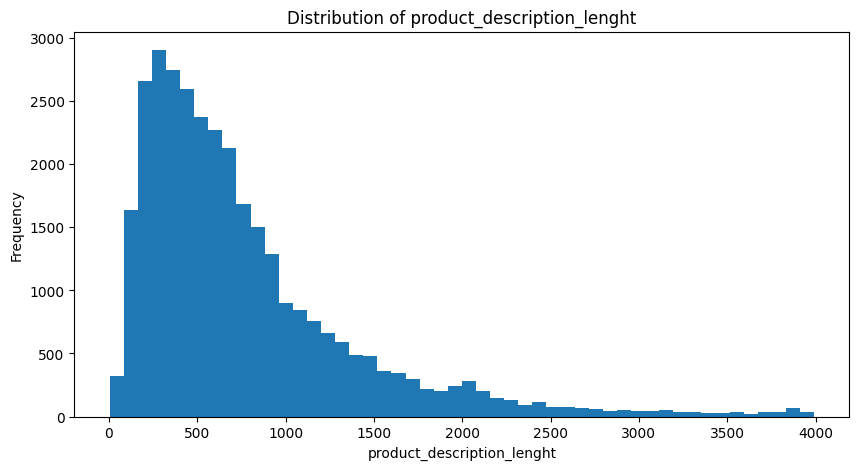

In [60]:
plot_df = (
    products_df
    .select("product_description_lenght")
    .drop_nulls()
    .to_series()
)

plt.figure(figsize=(10, 5))
plt.hist(plot_df, bins=50)
plt.xlabel("product_description_lenght")
plt.ylabel("Frequency")
plt.title("Distribution of product_description_lenght")
plt.show()

The distribution shows a long right tail, so the maximum value appears to be an uncommon but plausible case rather than an obvious outlier.

First, we check how many non-null product categories exist in the products table.

In [62]:
products_df["product_category_name"].unique().count()

73

Next, we inspect the translation mapping table and compare category coverage.

In [63]:
product_category_name_translation_df = pl.read_csv(MAPPINGS_DIR / "product_category_name_translation.csv")

product_category_name_translation_df.describe()

statistic,product_category_name,product_category_name_english
str,str,str
"""count""","""71""","""71"""
"""null_count""","""0""","""0"""
"""mean""",null,null
"""std""",null,null
"""min""","""agro_industria_e_comercio""","""agro_industry_and_commerce"""
"""25%""",null,null
"""50%""",null,null
"""75%""",null,null
"""max""","""utilidades_domesticas""","""watches_gifts"""


In [64]:
product_category_name_translation_df["product_category_name"].unique().count()

71

The translation table covers 71 product categories, while the products dataset contains 73 non-null unique categories. This means that 2 categories are not covered by the mapping table and will need to be translated manually or handled explicitly during transformation.

# Sellers

This table describes merchant-level location attributes and may later be used for seller analysis, geographic segmentation, and marketplace-side metrics. At this stage, the goal is to inspect schema completeness and basic structural patterns.

In [73]:
sellers_df = pl.read_csv(SOURCE_DIR / "olist_sellers_dataset.csv")

sellers_df.describe()

statistic,seller_id,seller_zip_code_prefix,seller_city,seller_state
str,str,f64,str,str
"""count""","""3095""",3095.0,"""3095""","""3095"""
"""null_count""","""0""",0.0,"""0""","""0"""
"""mean""",null,32291.059451,null,null
"""std""",null,32713.45383,null,null
"""min""","""0015a82c2db000af6aaaf3ae2ecb05…",1001.0,"""04482255""","""AC"""
"""25%""",null,7094.0,null,null
"""50%""",null,14940.0,null,null
"""75%""",null,65072.0,null,null
"""max""","""ffff564a4f9085cd26170f47323937…",99730.0,"""xaxim""","""SP"""


At least one `seller_city` value contains numeric characters, which suggests a data quality issue in the raw dataset and should be addressed during the cleaning stage.

# Interim conclusions

Based on this first exploratory pass, several practical themes already stand out:

1. **Raw files appear structurally usable**, so the dataset is suitable for a batch-oriented MVP pipeline.
2. **Some quality issues are already visible**, especially in text-heavy and mapping-related data.
3. **Several tables will require business-rule validation during transformation**, not just schema cleaning.
4. **The translation and review-related files deserve extra attention**, because alignment and text-quality issues may propagate into downstream analytics.

# What this means for the next stage

During Bronze/Silver work, the main focus should be on:

- preserving raw inputs as-is in Bronze
- standardizing datatypes and null handling in Silver
- checking key consistency between related tables
- documenting explicit cleaning rules instead of silently “fixing” suspicious values

This notebook provides the baseline observations for that next step.